# Putting many TinyRNNs onto one GPU

Here we investigate a potential speed-up obtained by training many TinyRNNs with the same training data. This means we can run all hyperparameters on the same loop. Could be an upwards of 100x speed up.

In [ ]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
from NM_TinyRNN.code.models import training_fast as speedrun
from NM_TinyRNN.code.models import datasets as ds
from NM_TinyRNN.code.models import rnns
# write some code to further parallelise the training and test it here
from NM_TinyRNN.code.models import nested_cv as nc
from NM_TinyRNN.code.models import nested_cv_io as save_data
from NM_TinyRNN.code.models import nested_jobs

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload


CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

%load_ext autoreload

In [ ]:

# let's test some code!
test_data_path = DATA_PATH / "bayes_optimal"
test_save_path  = './NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy'
reload(save_data)
reload(ds)
reload(nc)
reload(speedrun)
reload(rnns)
# we use a trainer with ensemble model training across hyperparameters
trainer = speedrun.TrainerGPU(weight_seeds = list(range(1,11)),
                        sparsity_lambdas = [1e-7],
                        energy_lambdas = [1e-1,0.01],
                        hebbian_lambdas = [1.0,0.1,0.01],
                        covariance_lambdas = [10.0,1.0,0.1])
model = rnns.TinyRNN(rnn_type = 'monoGRU',nonlinearity = 'relu', hidden_size = 2,
                     input_encoding='onehot',input_forced_choice = False)
dataset = ds.AB_Dataset(test_data_path, sequence_length = 64)
## You may test the trainer class to fit a single model:

final_state_dict, config, loss_dict = trainer.fit(model, dataset)


Sequence length 64 excludes 9.0% of trials
Parallelizing 180 models on cpu


 15%|█▍        | 1464/10000 [07:49<45:39,  3.12it/s]

Search complete. Best model index: 84. Val. loss: 0.07768289744853973


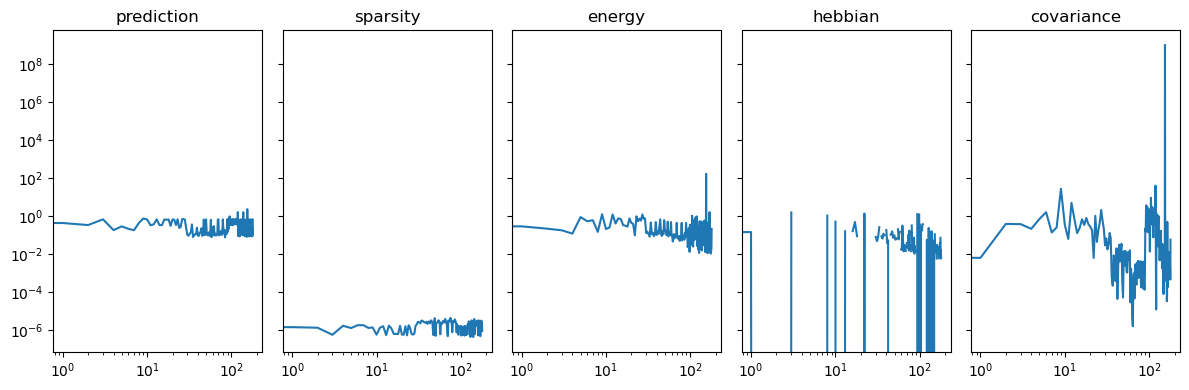

In [102]:
fig, ax = plt.subplots(1,len([x for x in loss_dict.keys()]), sharey=True, figsize=(12,4))
for i, (k,v) in enumerate(loss_dict.items()):
    ax[i].loglog(np.arange(len(v)),v)
    ax[i].set_title(k)
plt.tight_layout()

[outer 1/10]  outer eval: 7 blocks  |  9 inner folds  |  saving to NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu
Parallelizing 30 models on cpu


  6%|▋         | 647/10000 [02:29<37:11,  4.19it/s]

Search complete. Best model index: 16. Val. loss: 0.0730012059211731
  Saved outer_fold_1/inner_fold_3 -> NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy/outer_fold_1/inner_fold_3  (val_loss=0.0730, eval_loss=0.1003)
Parallelizing 30 models on cpu


  8%|▊         | 791/10000 [03:06<36:09,  4.24it/s]


[0.0902472510933876, 0.0572485476732254, 0.11722062528133392, 0.0730012059211731, 0.1361960470676422, 0.09346667677164078, 0.10596150159835815, 0.10610660165548325, 0.09904059767723083]


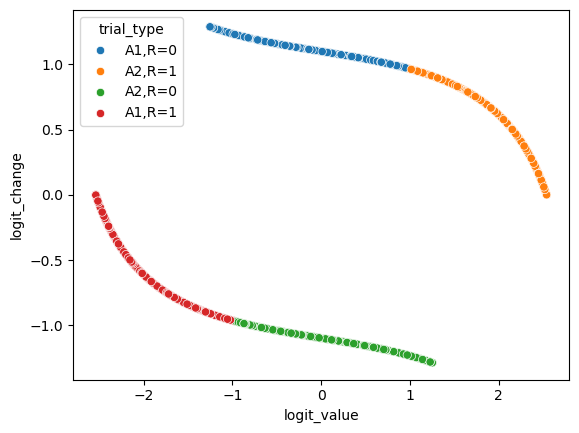

Search complete. Best model index: 21. Val. loss: 0.1361960470676422
  Saved outer_fold_1/inner_fold_4 -> NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy/outer_fold_1/inner_fold_4  (val_loss=0.1362, eval_loss=0.0921)
Search complete. Best model index: 24. Val. loss: 0.09346667677164078
  Saved outer_fold_1/inner_fold_5 -> NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy/outer_fold_1/inner_fold_5  (val_loss=0.0935, eval_loss=0.0991)
Search complete. Best model index: 10. Val. loss: 0.0902472510933876
  Saved outer_fold_1/inner_fold_0 -> NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy/outer_fold_1/inner_fold_0  (val_loss=0.0902, eval_loss=0.0987)
Search complete. Best model index: 21. Val. loss: 0.10610660165548325
  Saved outer_fold_1/inner_fold_7 -> NM_TinyRNN/data/rnns/test/bayes_optimal/monoGRU/energy/outer_fold_1/inner_fold_7  (val_loss=0.1061, eval_loss=0.0882)
Search complete. Best model index: 21. Val. loss: 0.10596150159835815
  Saved outer_fold_1/inner_fold_

In [100]:
#Here we've got code to run all inner loops in parallel,  
splits = nc.nested_cv_splits(dataset)
trials_df = save_data.get_model_trial_by_trial_df(model, dataset, splits['inner_folds'][0])
sns.scatterplot(trials_df.query('forced_choice==0'), 
                x='logit_value', y='logit_change', hue='trial_type')
outer_results = nc.run_outer_fold(model, dataset,
                                  outer_loop_number = 1,
                                  n_outer_loops = 10,
                                  save_path = test_save_path,
                                  trainer_kwargs = {'weight_seeds':list(range(1,11)),
                                                'sparsity_lambdas':[1e-5],
                                                 'energy_lambdas':[1.0,1e-1,1e-2],
                                                 'hebbian_lambdas':[0.0],
                                                 'covariance_lambdas':[0.0]} )
print([d['val_loss'] for d in outer_results['inner_results']])


In [56]:
dataset.subject_df.dropna()

,episode,trial,forced_choice,choice,outcome,good_poke,prob_A,prob_B,logit_value,logit_past,logit_change,trial_type,session_folder_name,session_trial_idx,sequence_block_idx,block_trial_idx
1,0,1,0,1,1,1,0.151020,0.848980,1.726620,0.969401,0.757220,"A2,R=1",episode_0,1,0.0,1.0
2,0,2,1,0,0,1,0.100378,0.899622,2.193029,1.726620,0.466409,"A1,R=0",episode_0,2,0.0,2.0
3,0,3,0,1,1,1,0.082273,0.917727,2.411855,2.193029,0.218826,"A2,R=1",episode_0,3,0.0,3.0
4,0,4,0,1,1,1,0.076114,0.923886,2.496352,2.411855,0.084497,"A2,R=1",episode_0,4,0.0,4.0
5,0,5,0,1,0,1,0.228357,0.771643,1.217609,2.496352,-1.278743,"A2,R=0",episode_0,5,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,9,450,1,0,0,1,0.111460,0.888540,2.075916,1.514667,0.561249,"A1,R=0",episode_9,450,69.0,450.0
451,9,451,1,1,0,1,0.296084,0.703916,0.866014,2.075916,-1.209902,"A2,R=0",episode_9,451,69.0,451.0
452,9,452,0,1,1,1,0.160671,0.839329,1.653247,0.866014,0.787234,"A2,R=1",episode_9,452,69.0,452.0
453,9,453,0,1,1,1,0.103984,0.896016,2.153726,1.653247,0.500479,"A2,R=1",episode_9,453,69.0,453.0


In [87]:
dataset.subject_df.dropna(subset=['sequence_block_idx'])

,episode,trial,forced_choice,choice,outcome,good_poke,prob_A,prob_B,logit_value,logit_past,logit_change,trial_type,session_folder_name,session_trial_idx,sequence_block_idx,block_trial_idx
0,0,0,0,0,0,1,0.275000,0.725000,0.969401,NaN,NaN,"A1,R=0",episode_0,0,0.0,0.0
1,0,1,0,1,1,1,0.151020,0.848980,1.726620,0.969401,0.757220,"A2,R=1",episode_0,1,0.0,1.0
2,0,2,1,0,0,1,0.100378,0.899622,2.193029,1.726620,0.466409,"A1,R=0",episode_0,2,0.0,2.0
3,0,3,0,1,1,1,0.082273,0.917727,2.411855,2.193029,0.218826,"A2,R=1",episode_0,3,0.0,3.0
4,0,4,0,1,1,1,0.076114,0.923886,2.496352,2.411855,0.084497,"A2,R=1",episode_0,4,0.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,9,450,1,0,0,1,0.111460,0.888540,2.075916,1.514667,0.561249,"A1,R=0",episode_9,450,69.0,450.0
451,9,451,1,1,0,1,0.296084,0.703916,0.866014,2.075916,-1.209902,"A2,R=0",episode_9,451,69.0,451.0
452,9,452,0,1,1,1,0.160671,0.839329,1.653247,0.866014,0.787234,"A2,R=1",episode_9,452,69.0,452.0
453,9,453,0,1,1,1,0.103984,0.896016,2.153726,1.653247,0.500479,"A2,R=1",episode_9,453,69.0,453.0


In [94]:
reload(nested_jobs)
# for organising training of models, we aggregate an 'info_df', so we can keep track of paths and later also completion.
# this 'info_df' later becomes a scaffold pandas dataframe for analyses.

#see nested_jobs
test_df = nested_jobs.get_test_info_df()

test_df

#uncomment below to send jobs to HPC
test_df = nested_jobs.run_training(overwrite=True, test= True)

Submitting model training for q_learning_2D to HPC
Submitted batch job 2903725
Submitting model training for q_learning_2D to HPC
Submitted batch job 2903726
Submitting model training for q_learning_2D to HPC
Submitted batch job 2903727
Submitting model training for q_learning_2D to HPC
Submitted batch job 2903728
Submitting model training for q_learning_2D to HPC
Submitted batch job 2903729
Submitting model training for q_learning_2D to HPC
Submitted batch job 2903730
Submitting model training for q_learning_2D to HPC
Submitted batch job 2903731
Submitting model training for q_learning_2D to HPC
Submitted batch job 2903732
Submitting model training for q_learning_2D to HPC
Submitted batch job 2903733
Submitting model training for q_learning_2D to HPC
Submitted batch job 2903734
Submitting model training for q_learning_2D to HPC
Submitted batch job 2903735
Submitting model training for q_learning_2D to HPC
Submitted batch job 2903736
Submitting model training for q_learning_2D to HPC
S